In [1]:
# ==============================================================================
# 🌐 STEP 1: UNIVERSAL ENTERPRISE LIBRARIES IMPORT (LINEAR-FAMILY)
# ==============================================================================
import os
import sys
import warnings
from pathlib import Path

# Scientific Computing & Data Structures
import numpy as np
import pandas as pd

# Visualization Engine
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Ecosystem
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error
)

# Serialization & Production
import joblib

# Global Plotting & Warning Configurations
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print("✅ Universal Linear-Family Enterprise Suite imported successfully.")


✅ Universal Linear-Family Enterprise Suite imported successfully.


In [2]:
# ==============================================================================
# 🌐 STEP 2: ENTERPRISE DATA INGESTION & 3-SECOND RAPID AUDIT
# ==============================================================================
from pathlib import Path
import pandas as pd

def load_and_audit_dataset(file_path):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"❌ File not found at: {path.resolve()}")
        
    try:
        if path.suffix.lower() in ['.xlsx', '.xls']:
            df = pd.read_excel(path)
        else:
            df = pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        print("⚠️ UTF-8 decoding failed. Retrying with 'latin-1' encoding...")
        df = pd.read_csv(path, encoding='latin-1')
        
    print("=" * 70)
    print("📋 3-SECOND STRUCTURAL HEALTH AUDIT REPORT")
    print("=" * 70)
    print(f"File Source               : {path.name}")
    print(f"Total Observations (Rows) : {df.shape[0]:,}")
    print(f"Total Features (Columns)  : {df.shape[1]}")
    print(f"Numerical Columns         : {len(df.select_dtypes(include=['number']).columns)} cols")
    print(f"Categorical/Text Columns  : {len(df.select_dtypes(exclude=['number']).columns)} cols")
    print(f"Missing Value Cells       : {df.isnull().sum().sum():,} nulls ({df.isnull().sum().sum() / (df.shape[0]*df.shape[1]) * 100:.2f}%)")
    print(f"Memory Footprint in RAM   : {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
    print("=" * 70)
    return df

# Ingest Ames Housing Dataset
df = load_and_audit_dataset("data/house_price/train.csv")
display(df.head(5))


📋 3-SECOND STRUCTURAL HEALTH AUDIT REPORT
File Source               : train.csv
Total Observations (Rows) : 1,460
Total Features (Columns)  : 81
Numerical Columns         : 38 cols
Categorical/Text Columns  : 43 cols
Missing Value Cells       : 7,829 nulls (6.62%)
Memory Footprint in RAM   : 1.10 MB


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# ==============================================================================
# 🌐 STEP 3: AUTOMATED 3-BUCKET FEATURE SEGREGATOR
# ==============================================================================
import pandas as pd
import numpy as np

def segregate_features(df, target_col, user_drop_cols=None, cardinality_threshold=0.05):
    if user_drop_cols is None:
        drop_cols = []
    else:
        drop_cols = list(user_drop_cols)
        
    cont_cols = []
    cat_cols = []
    
    candidate_cols = [c for c in df.columns if c != target_col and c not in drop_cols]
    
    for col in candidate_cols:
        col_series = df[col]
        if pd.api.types.is_numeric_dtype(col_series):
            if col_series.nunique() <= 1:
                drop_cols.append(col)
            elif col_series.nunique() <= 2:
                cat_cols.append(col)
            else:
                cont_cols.append(col)
        elif pd.api.types.is_object_dtype(col_series) or pd.api.types.is_string_dtype(col_series):
            unique_ratio = col_series.nunique() / len(df)
            if unique_ratio > cardinality_threshold and col_series.nunique() > 50:
                drop_cols.append(col)
            else:
                cat_cols.append(col)
        else:
            cat_cols.append(col)
            
    print("=" * 70)
    print("🔍 FEATURE SEGREGATION REPORT")
    print("=" * 70)
    print(f"Target Column          : '{target_col}'")
    print(f"Continuous Features    : {len(cont_cols)} cols")
    print(f"Categorical Features   : {len(cat_cols)} cols")
    print(f"Dropped ID / Artifacts : {len(drop_cols)} cols -> {drop_cols}")
    print("=" * 70)
    
    return cont_cols, cat_cols, drop_cols

cont_cols, cat_cols, drop_cols = segregate_features(
    df, 
    target_col='SalePrice', 
    user_drop_cols=['Id']
)


🔍 FEATURE SEGREGATION REPORT
Target Column          : 'SalePrice'
Continuous Features    : 36 cols
Categorical Features   : 43 cols
Dropped ID / Artifacts : 1 cols -> ['Id']


In [4]:
# ==============================================================================
# 🌐 STEP 4: DATA HYGIENE AUDIT (DUPLICATES & MISSINGNESS PROFILER)
# ==============================================================================
import pandas as pd

def audit_and_clean_hygiene(df, drop_duplicates=True):
    print("=" * 70)
    print("🧹 STEP 4: DATA HYGIENE & PURITY REPORT")
    print("=" * 70)
    
    n_dups = df.duplicated().sum()
    if n_dups > 0:
        print(f"⚠️ FOUND {n_dups:,} EXACT DUPLICATE ROWS!")
        if drop_duplicates:
            df = df.drop_duplicates().reset_index(drop=True)
            print(f"✅ Cleaned: {n_dups:,} duplicates removed. New Shape: {df.shape}")
    else:
        print("✅ Zero duplicate rows found. Data integrity is clean.")
    print("-" * 70)

    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0].sort_values(ascending=False)
    
    if len(null_cols) > 0:
        null_report = pd.DataFrame({
            "Missing Count": null_cols,
            "Percentage (%)": (null_cols / len(df) * 100).round(2),
            "Data Type": [df[col].dtype for col in null_cols.index]
        })
        print(f"🚨 FOUND {len(null_cols)} COLUMNS WITH MISSING VALUES (Showing Top 8):")
        print(null_report.head(8).to_string())
    else:
        print("✅ Zero missing values across all features. Dataset is complete.")
    print("=" * 70)
    
    return df

df = audit_and_clean_hygiene(df, drop_duplicates=True)


🧹 STEP 4: DATA HYGIENE & PURITY REPORT
✅ Zero duplicate rows found. Data integrity is clean.
----------------------------------------------------------------------
🚨 FOUND 19 COLUMNS WITH MISSING VALUES (Showing Top 8):
             Missing Count  Percentage (%) Data Type
PoolQC                1453           99.52       str
MiscFeature           1406           96.30       str
Alley                 1369           93.77       str
Fence                 1179           80.75       str
MasVnrType             872           59.73       str
FireplaceQu            690           47.26       str
LotFrontage            259           17.74   float64
GarageType              81            5.55       str


In [5]:
# ==============================================================================
# 🌐 STEP 5: ENTERPRISE TRAIN-TEST SPLITTER (ZERO DATA LEAKAGE + TARGET GUARD)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def perform_zero_leakage_split(df, target_col, drop_cols=None, is_classification=False, apply_log_target=False, test_size=0.20, random_state=42):
    if drop_cols is None:
        drop_cols = []
        
    if df[target_col].isnull().any():
        n_dropped = df[target_col].isnull().sum()
        print(f"⚠️ Target Safety Guard: Dropping {n_dropped:,} rows where target '{target_col}' is NaN!")
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        
    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col]
    
    if not is_classification and apply_log_target:
        skew_before = y.skew()
        y = np.log1p(y)
        skew_after = y.skew()
        print(f"📈 Target Skewness Normalization: {skew_before:.2f} -> {skew_after:.2f} (Bell curve achieved!)")

    stratify_arg = y if is_classification else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify_arg
    )
    
    print("=" * 70)
    print("📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)")
    print("=" * 70)
    print(f"Total Records          : {len(df):,}")
    print(f"Training Matrix (X_tr) : {X_train.shape[0]:,} rows × {X_train.shape[1]} features ({(1-test_size)*100:.0f}%)")
    print(f"Testing Matrix  (X_te) : {X_test.shape[0]:,} rows × {X_test.shape[1]} features ({test_size*100:.0f}%)")
    print(f"Target Missing in y_tr : {y_train.isnull().sum()} nulls (Guaranteed Clean!)")
    print("=" * 70)
    
    return X_train, X_test, y_train, y_test

X_tr, X_te, y_tr, y_te = perform_zero_leakage_split(
    df, 
    target_col='SalePrice', 
    drop_cols=drop_cols, 
    apply_log_target=True
)


📈 Target Skewness Normalization: 1.88 -> 0.12 (Bell curve achieved!)
📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)
Total Records          : 1,460
Training Matrix (X_tr) : 1,168 rows × 79 features (80%)
Testing Matrix  (X_te) : 292 rows × 79 features (20%)
Target Missing in y_tr : 0 nulls (Guaranteed Clean!)


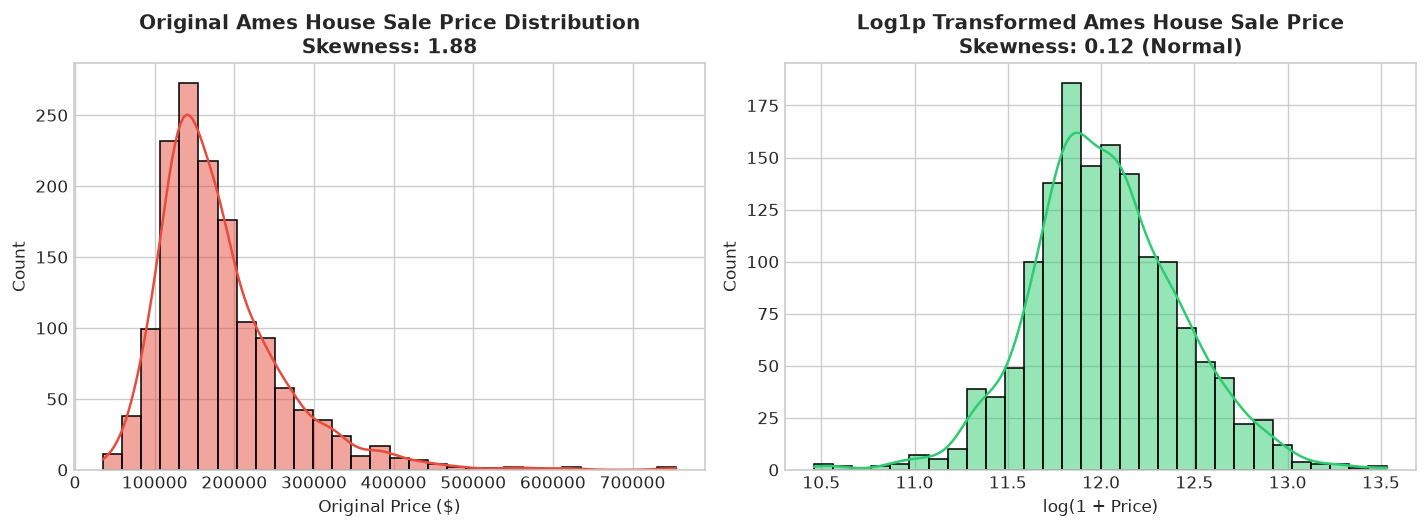

In [6]:
# ==============================================================================
# 🌐 STEP 6: TARGET ANALYSIS & TRANSFORMATION PROFILER
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def profile_target_distribution(y_original, y_transformed, target_name="Price"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    
    sns.histplot(y_original, kde=True, ax=axes[0], color='#e74c3c', bins=30)
    axes[0].set_title(f"Original {target_name} Distribution\nSkewness: {y_original.skew():.2f}", fontweight='bold')
    axes[0].set_xlabel("Original Price ($)")
    
    sns.histplot(y_transformed, kde=True, ax=axes[1], color='#2ecc71', bins=30)
    axes[1].set_title(f"Log1p Transformed {target_name}\nSkewness: {y_transformed.skew():.2f} (Normal)", fontweight='bold')
    axes[1].set_xlabel("log(1 + Price)")
    
    plt.tight_layout()
    plt.show()

profile_target_distribution(df['SalePrice'], np.log1p(df['SalePrice']), target_name="Ames House Sale Price")


In [7]:
# ==============================================================================
# 🌐 STEP 7: UNIVERSAL MASTER COLUMNTRANSFORMER (ZERO DATA LEAKAGE)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def build_universal_preprocessor(continuous_features, categorical_features, cat_impute_value="None"):
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=cat_impute_value)),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, continuous_features),
        ('cat', cat_pipeline, categorical_features)
    ])
    
    return preprocessor

def execute_safe_preprocessing(preprocessor, X_train, X_test, continuous_features, categorical_features):
    X_tr_proc = preprocessor.fit_transform(X_train)
    X_te_proc = preprocessor.transform(X_test)
    
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_encoded_names = list(cat_encoder.get_feature_names_out(categorical_features))
    all_feature_names = continuous_features + cat_encoded_names
    
    print("=" * 70)
    print("⚙️ PREPROCESSING COMPLETE (ZERO DATA LEAKAGE GUARANTEED)")
    print("=" * 70)
    print(f"Continuous Features Processed   : {len(continuous_features)} cols")
    print(f"Categorical Features Processed  : {len(categorical_features)} cols")
    print(f"One-Hot Dummy Features Created  : {len(cat_encoded_names)} cols")
    print(f"Total Model Input Dimensions    : {X_tr_proc.shape[1]} features (Massive Matrix!)")
    print(f"X_train Processed Shape         : {X_tr_proc.shape}")
    print(f"X_test Processed Shape          : {X_te_proc.shape}")
    print("=" * 70)
    
    return X_tr_proc, X_te_proc, all_feature_names

continuous_features, categorical_features = cont_cols, cat_cols
X_train, X_test = X_tr, X_te
preprocessor = build_universal_preprocessor(continuous_features, categorical_features)
X_train_final, X_test_final, all_names = execute_safe_preprocessing(
    preprocessor, X_train, X_test, continuous_features, categorical_features
)


⚙️ PREPROCESSING COMPLETE (ZERO DATA LEAKAGE GUARANTEED)
Continuous Features Processed   : 36 cols
Categorical Features Processed  : 43 cols
One-Hot Dummy Features Created  : 222 cols
Total Model Input Dimensions    : 258 features (Massive Matrix!)
X_train Processed Shape         : (1168, 258)
X_test Processed Shape          : (292, 258)


In [8]:
# ==============================================================================
# 🏆 STEP 8: SGDREGRESSOR HYPERPARAMETER TUNING VIA GRIDSEARCHCV
# ==============================================================================
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {
    'loss': ['squared_error', 'huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [1e-4, 1e-3, 1e-2],
    'learning_rate': ['adaptive', 'invscaling'],
    'eta0': [0.005, 0.01, 0.05]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

sgd_base = SGDRegressor(
    max_iter=5000, 
    tol=1e-3, 
    early_stopping=True, 
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=sgd_base,
    param_grid=param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train_final, y_tr)

best_sgd = grid_search.best_estimator_
best_params = grid_search.best_params_

print("=" * 70)
print("🏆 STEP 8: SGDREGRESSOR HYPERPARAMETER TUNING REPORT")
print("=" * 70)
print(f"Optimal Loss Function        : '{best_params['loss']}'")
print(f"Optimal Penalty Type         : '{best_params['penalty']}'")
print(f"Optimal Regularization Alpha : {best_params['alpha']:.5f}")
print(f"Optimal Learning Rate Policy : '{best_params['learning_rate']}'")
print(f"Optimal Initial Step (eta0)  : {best_params['eta0']}")
print(f"Best 5-Fold Cross-Val R²     : {grid_search.best_score_ * 100:.2f}%")
print(f"Epochs to Converge           : {best_sgd.n_iter_} iterations")
print(f"Model Intercept (log scale)  : {best_sgd.intercept_[0]:.4f}")
print("=" * 70)


🏆 STEP 8: SGDREGRESSOR HYPERPARAMETER TUNING REPORT
Optimal Loss Function        : 'huber'
Optimal Penalty Type         : 'l1'
Optimal Regularization Alpha : 0.01000
Optimal Learning Rate Policy : 'adaptive'
Optimal Initial Step (eta0)  : 0.05
Best 5-Fold Cross-Val R²     : 81.57%
Epochs to Converge           : 69 iterations
Model Intercept (log scale)  : 12.0428


In [9]:
# ==============================================================================
# ⚔️ STEP 9: THE GRAND 5-WAY BATTLE: OLS VS RIDGE VS LASSO VS ELASTICNET VS SGD
# ==============================================================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

ridge_alpha = 11.51
lasso_alpha = 0.00010
elastic_alpha = 0.00518

ols_m = LinearRegression().fit(X_train_final, y_tr)
ridge_m = Ridge(alpha=ridge_alpha, random_state=42).fit(X_train_final, y_tr)
lasso_m = Lasso(alpha=lasso_alpha, max_iter=10000, tol=1e-3, random_state=42).fit(X_train_final, y_tr)
elastic_m = ElasticNet(alpha=elastic_alpha, l1_ratio=0.1, max_iter=10000, tol=1e-3, random_state=42).fit(X_train_final, y_tr)
sgd_m = best_sgd

preds_log = {
    'OLS Linear Regression': ols_m.predict(X_test_final),
    'Ridge Regression (L2)': ridge_m.predict(X_test_final),
    'Lasso Regression (L1)': lasso_m.predict(X_test_final),
    'ElasticNet (L1 + L2)':  elastic_m.predict(X_test_final),
    'SGD Regressor (Iterative)': sgd_m.predict(X_test_final)
}

y_test_real = np.expm1(y_te)

models_dict = {
    'OLS Linear Regression': ols_m,
    'Ridge Regression (L2)': ridge_m,
    'Lasso Regression (L1)': lasso_m,
    'ElasticNet (L1 + L2)':  elastic_m,
    'SGD Regressor (Iterative)': sgd_m
}

rows = []
for name, mod in models_dict.items():
    p_log = preds_log[name]
    p_real = np.expm1(p_log)
    
    tr_r2 = r2_score(y_tr, mod.predict(X_train_final))
    te_r2 = r2_score(y_te, p_log)
    rmse = root_mean_squared_error(y_test_real, p_real)
    mae = mean_absolute_error(y_test_real, p_real)
    n_active = np.sum(mod.coef_ != 0)
    total_f = len(mod.coef_)
    
    rows.append({
        'Model Name': name,
        'Train R²': f"{tr_r2*100:.2f}%",
        'Test R²': f"{te_r2*100:.2f}%",
        'Real RMSE': f"${rmse:,.0f}",
        'Real MAE': f"${mae:,.0f}",
        'Active Features': f"{n_active} / {total_f}",
        'Sparsity (%)': f"{(total_f - n_active) / total_f * 100:.1f}%"
    })

battle_df = pd.DataFrame(rows)

print("=" * 95)
print("🏆 THE GRAND 5-WAY LINEAR BATTLE SHOWDOWN: OLS VS RIDGE VS LASSO VS ELASTICNET VS SGD")
print("=" * 95)
print(battle_df.to_string(index=False))
print("=" * 95)


🏆 THE GRAND 5-WAY LINEAR BATTLE SHOWDOWN: OLS VS RIDGE VS LASSO VS ELASTICNET VS SGD
               Model Name Train R² Test R² Real RMSE Real MAE Active Features Sparsity (%)
    OLS Linear Regression   94.49%  83.83%   $25,455  $15,519       258 / 258         0.0%
    Ridge Regression (L2)   91.59%  89.66%   $25,380  $16,618       258 / 258         0.0%
    Lasso Regression (L1)   93.71%  87.81%   $23,740  $15,220       201 / 258        22.1%
     ElasticNet (L1 + L2)   90.73%  89.43%   $26,028  $16,894       126 / 258        51.2%
SGD Regressor (Iterative)   81.77%  86.32%   $28,849  $18,594        13 / 258        95.0%


🔍 TOP 20 INFLUENTIAL DRIVERS SUMMARY TABLE:
        Feature  OLS_Weight  Ridge_Weight  ElasticNet_Weight  SGD_Weight
      GrLivArea    0.064655      0.058422           0.080140    0.118155
    OverallQual    0.055490      0.078098           0.084966    0.113887
    TotalBsmtSF    0.037820     -0.001834           0.000000    0.048159
      YearBuilt    0.059978      0.042589           0.047036    0.045939
   YearRemodAdd    0.023800      0.022940           0.023981    0.039013
     BsmtFinSF1    0.028957     -0.004709          -0.001016    0.031874
     GarageArea    0.033438      0.006810           0.005801    0.029048
     Fireplaces    0.011993      0.014386           0.016379    0.019352
     GarageCars    0.006188      0.042085           0.047036    0.017356
        LotArea    0.023648      0.014657           0.015458    0.016691
    LotFrontage    0.005925     -0.012033          -0.011267    0.006626
     WoodDeckSF    0.011683      0.016027           0.016105    0.004617
   Bsmt

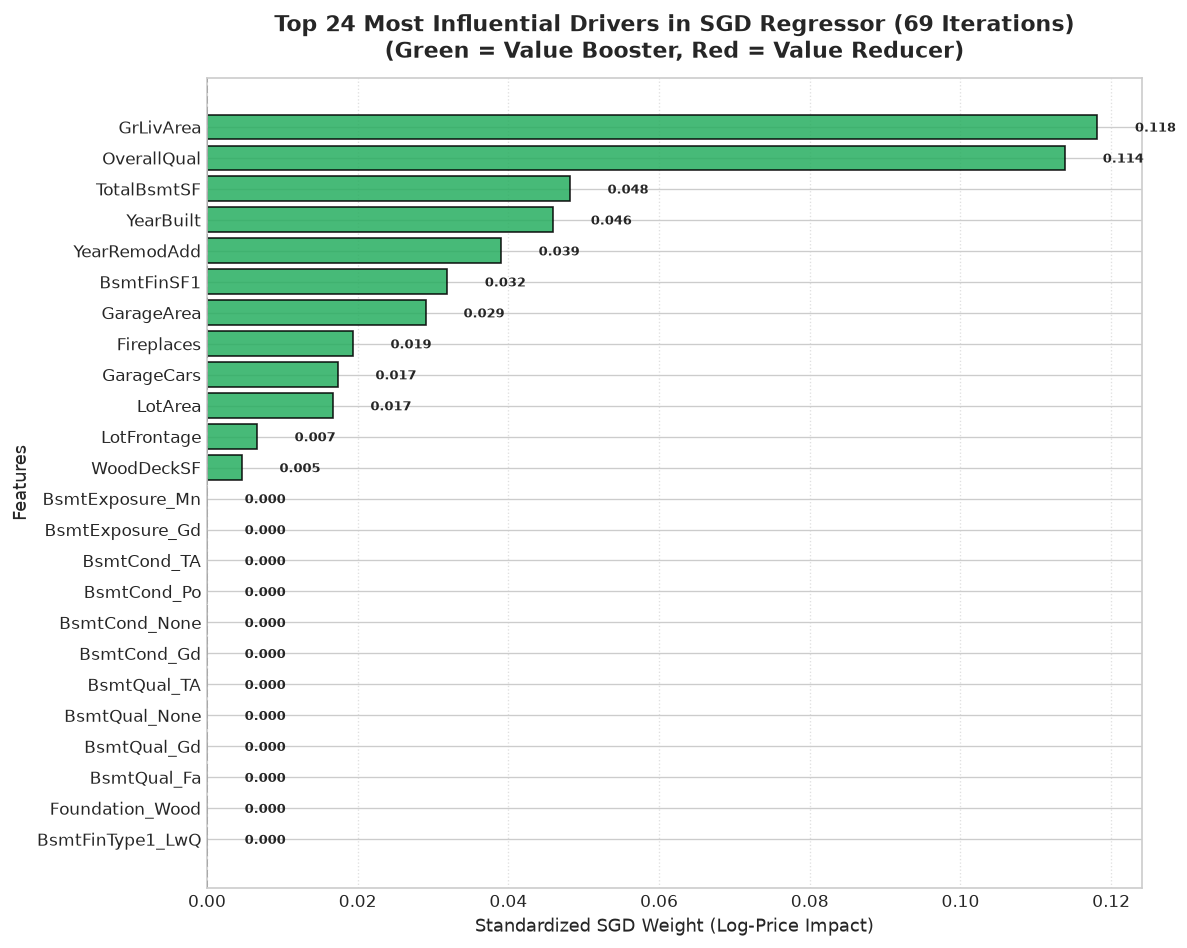

In [10]:
# ==============================================================================
# 📊 STEP 10: SGD FEATURE IMPORTANCE DASHBOARD (TOP 24 DRIVERS)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

weights_df = pd.DataFrame({
    'Feature': all_names,
    'OLS_Weight': ols_m.coef_,
    'Ridge_Weight': ridge_m.coef_,
    'ElasticNet_Weight': elastic_m.coef_,
    'SGD_Weight': best_sgd.coef_
})

weights_df['abs_sgd'] = weights_df['SGD_Weight'].abs()
top_pos = weights_df.sort_values(by='SGD_Weight').tail(12)
top_neg = weights_df.sort_values(by='SGD_Weight').head(12)
top_drivers = pd.concat([top_neg, top_pos])

plt.figure(figsize=(10, 8))
colors = ['#27ae60' if w > 0 else '#e74c3c' for w in top_drivers['SGD_Weight']]

bars = plt.barh(
    top_drivers['Feature'], 
    top_drivers['SGD_Weight'], 
    color=colors, 
    edgecolor='black', 
    alpha=0.85
)
plt.axvline(0, color='black', linestyle='--', linewidth=1.2)
plt.title(
    f'Top 24 Most Influential Drivers in SGD Regressor ({best_sgd.n_iter_} Iterations)\n(Green = Value Booster, Red = Value Reducer)', 
    fontsize=13, 
    fontweight='bold',
    pad=12
)
plt.xlabel('Standardized SGD Weight (Log-Price Impact)', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.6)

for bar in bars:
    w = bar.get_width()
    offset = 0.005 if w >= 0 else -0.02
    plt.text(w + offset, bar.get_y() + 0.25, f'{w:.3f}', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print("🔍 TOP 20 INFLUENTIAL DRIVERS SUMMARY TABLE:")
print("=" * 80)
print(weights_df.sort_values(by='abs_sgd', ascending=False)[['Feature', 'OLS_Weight', 'Ridge_Weight', 'ElasticNet_Weight', 'SGD_Weight']].head(20).to_string(index=False))
print("=" * 80)


In [11]:
# ==============================================================================
# 🏭 STEP 11: PRODUCTION PIPELINE SERIALIZATION & LIVE INFERENCE TEST
# ==============================================================================
import joblib
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

production_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('sgd_regressor', best_sgd)
])

production_pipeline.fit(X_tr, y_tr)

model_dir = Path('production_models')
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / 'house_price_sgd_pipeline.joblib'

joblib.dump(production_pipeline, model_path)

print("=" * 70)
print("🏭 ENTERPRISE PRODUCTION ARTIFACT SUMMARY")
print("=" * 70)
print(f"✅ Full Production Pipeline Saved: {model_path}")
print(f"   Artifact File Size           : {model_path.stat().st_size / 1024:.2f} KB")
print("=" * 70)

loaded_pipeline = joblib.load(model_path)
sample_house = X_te.iloc[0:1]

pred_log_price = loaded_pipeline.predict(sample_house)[0]
predicted_dollars = np.expm1(pred_log_price)
actual_dollars = np.expm1(y_te.iloc[0])

print("\n🧪 LIVE REAL-TIME AMES HOUSE SGD VALUATION TEST (1 PROPERTY):")
print("-" * 65)
print(f"   • Overall Quality (1-10) : {sample_house['OverallQual'].values[0]}")
print(f"   • Ground Living Area     : {sample_house['GrLivArea'].values[0]:,} sq ft")
print(f"   • Neighborhood           : {sample_house['Neighborhood'].values[0]}")
print(f"   • Year Built             : {sample_house['YearBuilt'].values[0]}")
print(f"   • Total Basement Area    : {sample_house['TotalBsmtSF'].values[0]:,} sq ft")
print("-" * 65)
print(f"   🎯 Model Predicted Price : ${predicted_dollars:,.0f}")
print(f"   🏷️ Actual Selling Price  : ${actual_dollars:,.0f}")
diff = abs(predicted_dollars - actual_dollars)
print(f"   📊 Valuation Difference  : ${diff:,.0f} ({diff/actual_dollars*100:.1f}%)")
print("=" * 70)


🏭 ENTERPRISE PRODUCTION ARTIFACT SUMMARY
✅ Full Production Pipeline Saved: production_models/house_price_sgd_pipeline.joblib
   Artifact File Size           : 20.65 KB

🧪 LIVE REAL-TIME AMES HOUSE SGD VALUATION TEST (1 PROPERTY):
-----------------------------------------------------------------
   • Overall Quality (1-10) : 6
   • Ground Living Area     : 1,068 sq ft
   • Neighborhood           : Sawyer
   • Year Built             : 1963
   • Total Basement Area    : 1,059 sq ft
-----------------------------------------------------------------
   🎯 Model Predicted Price : $146,933
   🏷️ Actual Selling Price  : $154,500
   📊 Valuation Difference  : $7,567 (4.9%)
